In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/vit-arch.png
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/torchvision-1.7-cp37-cp37m-linux_x86_64.whl
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/attn-distance.png
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/benchmarks-chart.png
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/__results__.html
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/multi-headed-attention.png
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/__resultx__.html
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/torch-1.7-cp37-cp37m-linux_x86_64.whl
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/transformer-arch.png
/kaggle/input/notebooks/abhinand05/vision-transformer-vit-tutorial-baseline/vision-transformer.png
/

# Digital Image Forgery Detection using Vision Transformers (ViT)
## Research Project: Combined Training on CASIA 1 and CASIA 2 Datasets

### Abstract:
This project aims to develop a robust binary classification model capable of distinguishing between **Authentic** images and **Tampered** images (forgeries). We leverage the **Vision Transformer (ViT)** architecture, which utilizes a self-attention mechanism to capture long-range dependencies and fine-grained inconsistencies caused by splicing or copy-move operations.

### Environment Setup:
* **Accelerator:** GPU (T4 or P100) enabled for high-speed training.
* **Libraries:** PyTorch, Torchvision, Scikit-learn, and Matplotlib.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, ConcatDataset
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device detected: {device}")

Device detected: cuda


In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

## 1. Data Preprocessing & Augmentation

In this stage, we merge **CASIA v1** and **CASIA v2** to provide the model with a diverse set of forgery examples.

### Applied Transformations:
1. **Resize:** Standardizing all images to $224 \times 224$ pixels.
2. **Data Augmentation:** Applying `RandomHorizontalFlip` to increase model generalization and prevent overfitting.
3. **Normalization:** Utilizing ImageNet mean and standard deviation values to ensure stable convergence.
4. **Data Splitting:** Allocating 80% of the data for training and 20% for validation.

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),     
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

path_casia1 = '/kaggle/input/datasets/sophatvathana/casia-dataset/CASIA1'
path_casia2 = '/kaggle/input/datasets/sophatvathana/casia-dataset/CASIA2'


try:
    ds1 = datasets.ImageFolder(root=path_casia1, transform=transform)
    ds2 = datasets.ImageFolder(root=path_casia2, transform=transform)
    
    full_dataset = ConcatDataset([ds1, ds2])
    print(f"Total images combined: {len(full_dataset)}")
except Exception as e:
    print(f"Check your paths! Error: {e}")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=4)

Total images combined: 14335


## 2. Model Architecture & Fine-tuning Strategy

We utilize a pre-trained **ViT-B/16** model. To adapt this model for forgery detection without losing its pre-learned feature extraction capabilities, we implement a selective unfreezing strategy.

### Fine-tuning Details:
* **Initial Freeze:** All backbone parameters are initially frozen.
* **Selective Unfreeze:** We unfreeze the **last 4 Transformer Encoder layers** and the **Classification Head**. This allows the model to learn specific high-frequency noise patterns and edge inconsistencies typical of digital manipulation.

In [5]:
model = models.vit_b_16(weights='IMAGENET1K_V1')

model.heads = nn.Linear(768, 2)

for param in model.parameters():
    param.requires_grad = False

for layer in model.encoder.layers[-4:]:
    for param in layer.parameters():
        param.requires_grad = True
for param in model.heads.parameters():
    param.requires_grad = True

model = model.to(device)
print("Model is ready with unfreezed top layers!")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 209MB/s] 


Model is ready with unfreezed top layers!


## 3. Training and Validation Process

The model is trained for 10 epochs using the **Cross-Entropy Loss** function and the **Adam** optimizer. A relatively low learning rate ($5 \times 10^{-5}$) is used to ensure a smooth fine-tuning process.

* **Checkpoints:** The best-performing model weights are automatically saved as `vit_casia_combined_best.pth`.

In [8]:
criterion = FocalLoss(alpha=1, gamma=2) 

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                         lr=1e-5, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        start_time = time.time()
        
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels) # سينفذ الآن Focal Loss تلقائياً
            loss.backward()
            optimizer.step()            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(train_loss/len(train_loader))
        history['val_loss'].append(val_loss/len(val_loader))
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)
        
        epoch_time = time.time() - start_time
        epoch_loss = train_loss / len(train_loader)
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = history['val_acc'][-1]
        epoch_val_loss = history['val_loss'][-1]   

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Time: {epoch_time:.2f}s | "
              f"Train Loss: {epoch_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.2f}%")        
        torch.save(model.state_dict(), 'vit_casia_combined_best.pth')
        
    return history

history = train_model(model, train_loader, val_loader, epochs=10)

Epoch [1/10] | Time: 315.73s | Train Loss: 0.1241 | Train Acc: 74.84% | Val Loss: 0.1407 | Val Acc: 68.96%
Epoch [2/10] | Time: 314.10s | Train Loss: 0.1120 | Train Acc: 77.72% | Val Loss: 0.1423 | Val Acc: 71.05%
Epoch [3/10] | Time: 313.88s | Train Loss: 0.1029 | Train Acc: 79.80% | Val Loss: 0.1442 | Val Acc: 69.52%
Epoch [4/10] | Time: 313.97s | Train Loss: 0.0960 | Train Acc: 81.28% | Val Loss: 0.1469 | Val Acc: 68.47%
Epoch [5/10] | Time: 313.27s | Train Loss: 0.0906 | Train Acc: 82.12% | Val Loss: 0.1547 | Val Acc: 68.29%
Epoch [6/10] | Time: 313.87s | Train Loss: 0.0854 | Train Acc: 83.04% | Val Loss: 0.1558 | Val Acc: 69.83%
Epoch [7/10] | Time: 314.62s | Train Loss: 0.0813 | Train Acc: 84.06% | Val Loss: 0.1616 | Val Acc: 69.65%
Epoch [8/10] | Time: 313.93s | Train Loss: 0.0782 | Train Acc: 84.30% | Val Loss: 0.1651 | Val Acc: 72.10%
Epoch [9/10] | Time: 313.59s | Train Loss: 0.0748 | Train Acc: 85.25% | Val Loss: 0.1738 | Val Acc: 71.40%
Epoch [10/10] | Time: 313.56s | Train

## 4. Performance Metrics & Visualization

Once training is complete, we visualize the **Learning Curves** (Accuracy and Loss) for both training and validation sets. These graphs are critical for analyzing the model's learning behavior and ensuring it has successfully generalized to unseen data.

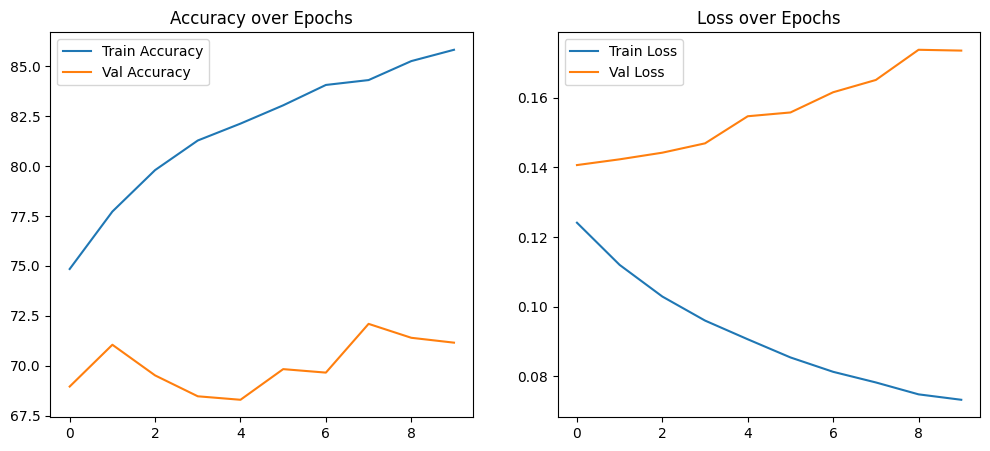

In [9]:
def plot_history(history):
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_history(history)

## 5. Statistical Analysis & Final Report

To provide a comprehensive academic analysis, we generate:
1. **Classification Report:** Detailed Precision, Recall, and F1-Score.
2. **Confusion Matrix:** Visualizing the True Positives (Tp) and True Negatives (Au) to assess the model's reliability in a real-world scenario.


  ACADEMIC CLASSIFICATION REPORT
                precision    recall  f1-score   support

Authentic (Au)       0.76      0.73      0.74      1673
 Tampered (Tp)       0.64      0.68      0.66      1194

      accuracy                           0.71      2867
     macro avg       0.70      0.70      0.70      2867
  weighted avg       0.71      0.71      0.71      2867


Generating Confusion Matrix...


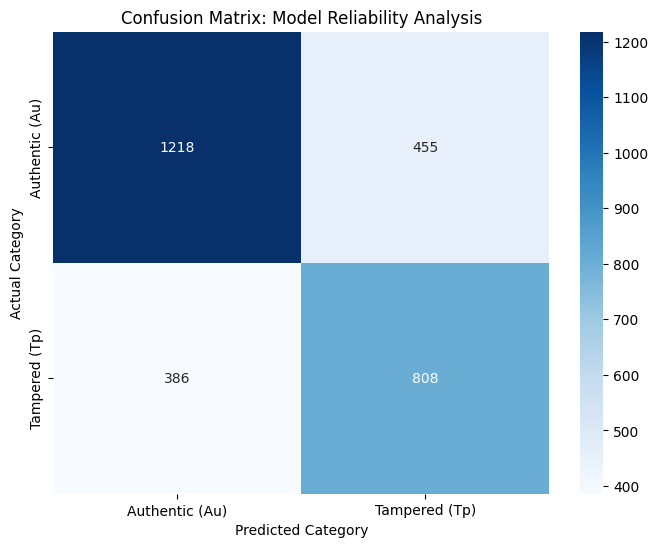

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def generate_final_report(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    # We use torch.no_grad() because we are only testing, not training
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 1. Print Text-based Classification Report
    print("\n" + "="*30)
    print("  ACADEMIC CLASSIFICATION REPORT")
    print("="*30)
    # Target names match the CASIA folders (Au: Authentic, Tp: Tampered)
    target_names = ['Authentic (Au)', 'Tampered (Tp)']
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # 2. Plot Visual Confusion Matrix
    print("\nGenerating Confusion Matrix...")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names)
    plt.title('Confusion Matrix: Model Reliability Analysis')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.show()

# Execute the report using the validation data
generate_final_report(model, val_loader)

In [11]:
def check_train_accuracy(model, train_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    print(f"Current Accuracy on Training Set: {100 * correct / total:.2f}%")


check_train_accuracy(model, train_loader)

Current Accuracy on Training Set: 89.28%


In [12]:
import torch
import numpy as np

def extract_and_save_features(model, loader, device, filename_prefix):
    model.eval()    
    
    original_heads = model.heads
    model.heads = torch.nn.Identity()
    
    features = []
    labels = []
    
    print(f"Starting feature extraction for {filename_prefix}...")
    
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            output = model(images)
            
            features.append(output.cpu().numpy())
            labels.append(targets.numpy())
            
    features_array = np.concatenate(features, axis=0)
    labels_array = np.concatenate(labels, axis=0)
    
    np.save(f'{filename_prefix}_features.npy', features_array)
    np.save(f'{filename_prefix}_labels.npy', labels_array)
    
    print(f"Completed! Shape: {features_array.shape}")
    
    model.heads = original_heads
    return features_array, labels_array

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, y_train = extract_and_save_features(model, train_loader, device, 'train')

X_val, y_val = extract_and_save_features(model, val_loader, device, 'val')

Starting feature extraction for train...
Completed! Shape: (11468, 768)
Starting feature extraction for val...
Completed! Shape: (2867, 768)


In [14]:
import torch
import numpy as np
import os

def extract_features_to_disk(model, loader, device, split_name):
    model.eval()
    
    original_heads = model.heads
    model.heads = torch.nn.Identity()
    
    features = []
    labels = []
    
    print(f"--- Extracting {split_name} features ---")
    with torch.no_grad():
        for i, (images, targets) in enumerate(loader):
            images = images.to(device)
            output = model(images)
            features.append(output.cpu().numpy())
            labels.append(targets.numpy())
            if i % 20 == 0:
                print(f"Batch {i}/{len(loader)} processed...")
    
    features_array = np.concatenate(features, axis=0)
    labels_array = np.concatenate(labels, axis=0)
    
    np.save(f'X_{split_name}.npy', features_array)
    np.save(f'y_{split_name}.npy', labels_array)
    
    model.heads = original_heads
    print(f"Finished! {split_name} shape: {features_array.shape}")
    return features_array, labels_array

X_train, y_train = extract_features_to_disk(model, train_loader, device, 'train')
X_val, y_val = extract_features_to_disk(model, val_loader, device, 'val')

--- Extracting train features ---
Batch 0/180 processed...
Batch 20/180 processed...
Batch 40/180 processed...
Batch 60/180 processed...
Batch 80/180 processed...
Batch 100/180 processed...
Batch 120/180 processed...
Batch 140/180 processed...
Batch 160/180 processed...
Finished! train shape: (11468, 768)
--- Extracting val features ---
Batch 0/45 processed...
Batch 20/45 processed...
Batch 40/45 processed...
Finished! val shape: (2867, 768)


In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',       
    device='cuda',             
    early_stopping_rounds=50,
    random_state=42,
    eval_metric=['logloss', 'error']
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-logloss:0.67540	validation_0-error:0.41646
[1]	validation_0-logloss:0.67140	validation_0-error:0.41646
[2]	validation_0-logloss:0.66796	validation_0-error:0.41646
[3]	validation_0-logloss:0.66464	validation_0-error:0.41646
[4]	validation_0-logloss:0.66100	validation_0-error:0.41646
[5]	validation_0-logloss:0.65767	validation_0-error:0.41646
[6]	validation_0-logloss:0.65465	validation_0-error:0.41646
[7]	validation_0-logloss:0.65184	validation_0-error:0.41646
[8]	validation_0-logloss:0.64876	validation_0-error:0.41611
[9]	validation_0-logloss:0.64588	validation_0-error:0.41577
[10]	validation_0-logloss:0.64296	validation_0-error:0.41577
[11]	validation_0-logloss:0.64027	validation_0-error:0.41542
[12]	validation_0-logloss:0.63772	validation_0-error:0.41263
[13]	validation_0-logloss:0.63538	validation_0-error:0.40809
[14]	validation_0-logloss:0.63254	validation_0-error:0.40181
[15]	validation_0-logloss:0.63033	validation_0-error:0.40112
[16]	validation_0-logloss:0.62803	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=50,
              enable_categorical=False, eval_metric=['logloss', 'error'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)


--- Final Hybrid Model Report (ViT + XGBoost) ---
              precision    recall  f1-score   support

   Authentic       0.77      0.78      0.77      1673
    Tampered       0.69      0.67      0.68      1194

    accuracy                           0.73      2867
   macro avg       0.73      0.72      0.73      2867
weighted avg       0.73      0.73      0.73      2867



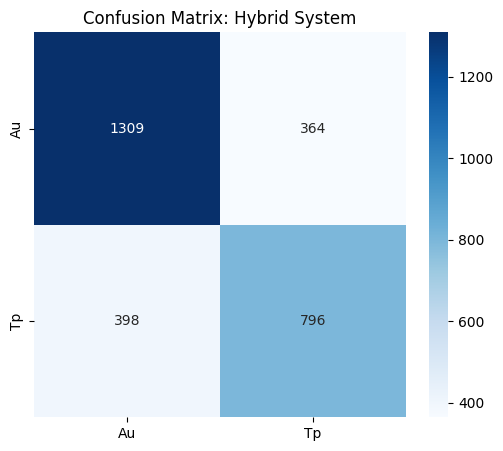

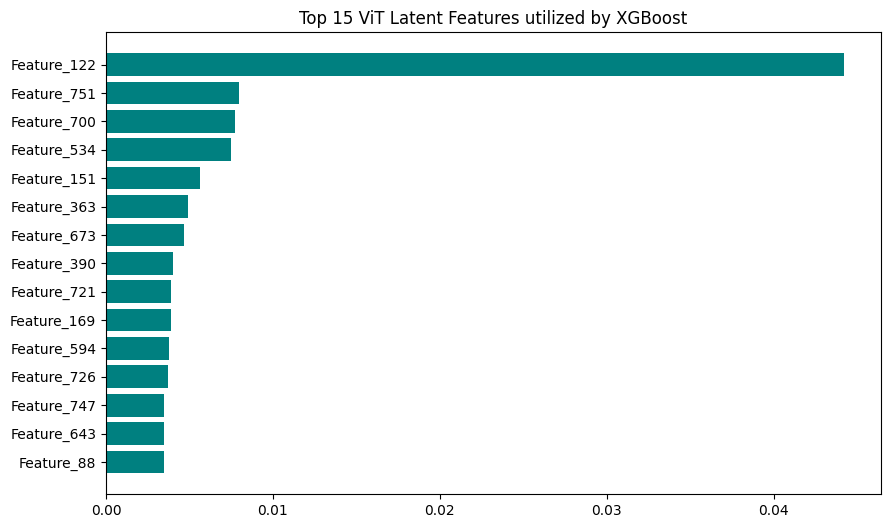

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = xgb_model.predict(X_val)
print("\n--- Final Hybrid Model Report (ViT + XGBoost) ---")
print(classification_report(y_val, y_pred, target_names=['Authentic', 'Tampered']))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Au', 'Tp'], yticklabels=['Au', 'Tp'])
plt.title('Confusion Matrix: Hybrid System')
plt.show()

plt.figure(figsize=(10, 6))
feat_importances = xgb_model.feature_importances_
top_indices = np.argsort(feat_importances)[-15:]
plt.barh(range(len(top_indices)), feat_importances[top_indices], color='teal')
plt.yticks(range(len(top_indices)), [f'Feature_{i}' for i in top_indices])
plt.title('Top 15 ViT Latent Features utilized by XGBoost')
plt.show()

In [22]:
# حفظ موديل الـ Boosting
import joblib
joblib.dump(xgb_model, 'final_hybrid_model.dat')

np.save('final_predictions.npy', y_pred)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = xgb_model.predict(X_val)

final_acc = accuracy_score(y_val, y_pred)
print(f"--- Final Hybrid System Accuracy: {final_acc*100:.2f}% ---")


--- Final Hybrid System Accuracy: 73.42% ---


In [24]:
misclassified_idx = np.where(y_pred != y_val)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")



Number of misclassified images: 762


****Stacking Classifier****

In [27]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=500, 
        learning_rate=0.02, 
        max_depth=6, 
        tree_method='hist', 
        device='cuda', 
        random_state=42
    ))
]

meta_model = LogisticRegression()

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,    
    passthrough=False   
)

print("Starting Stacking Training... This might take a few minutes.")

stacking_model.fit(X_train, y_train)

print("Stacking Training Completed!")

Starting Stacking Training... This might take a few minutes.
Stacking Training Completed!


In [28]:
y_pred_stack = stacking_model.predict(X_val)

stack_acc = accuracy_score(y_val, y_pred_stack)

print("\n" + "="*45)
print(f"FINAL STACKING ACCURACY: {stack_acc*100:.2f}%")
print("="*45)

print("\nFull Classification Report:")
print(classification_report(y_val, y_pred_stack, target_names=['Authentic', 'Tampered']))


FINAL STACKING ACCURACY: 72.10%

Full Classification Report:
              precision    recall  f1-score   support

   Authentic       0.76      0.76      0.76      1673
    Tampered       0.67      0.66      0.66      1194

    accuracy                           0.72      2867
   macro avg       0.71      0.71      0.71      2867
weighted avg       0.72      0.72      0.72      2867



--- Final Academic Report: Stacking Ensemble ---
              precision    recall  f1-score   support

   Authentic       0.76      0.76      0.76      1673
    Tampered       0.67      0.66      0.66      1194

    accuracy                           0.72      2867
   macro avg       0.71      0.71      0.71      2867
weighted avg       0.72      0.72      0.72      2867



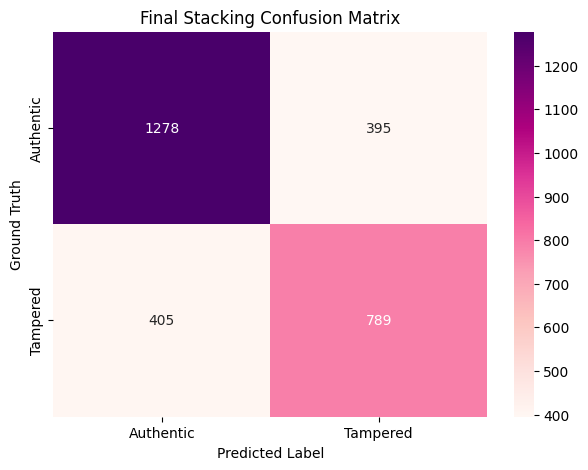

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_final = stacking_model.predict(X_val)

print("--- Final Academic Report: Stacking Ensemble ---")
print(classification_report(y_val, y_pred_final, target_names=['Authentic', 'Tampered']))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Authentic', 'Tampered'], 
            yticklabels=['Authentic', 'Tampered'])
plt.title('Final Stacking Confusion Matrix')
plt.ylabel('Ground Truth')
plt.xlabel('Predicted Label')
plt.show()

In [31]:
import joblib
joblib.dump(stacking_model, 'stacking_forgery_detector_72acc.pkl')
print("Model saved successfully!")

Model saved successfully!
